## This is a sample Machine Learning project that exemplifies how to proceed Count Data Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Tabulate, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import exp, factorial
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP,ZeroInflatedPoisson
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson
from statsmodels.iolib.summary2 import summary_col
from statstests.tests import overdisp
from scipy import stats
from scipy.interpolate import interp1d
from tabulate import tabulate
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Violations = f(staff, post, corruption). Poisson Regression - Count Data.

This is a simple use-case for Generalized Linear Models (GLMs) of type Poisson Regression for Count Data or Rate Data (PR). For other Count Data regression types (e.g. NB, ZIP, ZINB), see other examples at this same project directory. For a problem to be a Regression case of Count Data type (either PR, NB, ZIP or ZINB), the dependent variable must be a count, i.e., quantitative, discrete (only integers), non-negative and associated with a defined exposure - generating a rate for the count per exposure unit. The predictors can be either qualitative (must pass dummyzation) or quantitative variables. Here, we have a dataset, available at this National Bureau of Economic Research [link](https://www.nber.org/system/files/working_papers/w12312/w12312.pdf) , that aims to explain a regression of unpaid (ignored) parking violation tickets, aggregated at country·year level, per diplomat on the post categories before or after law enforcement started being applied (2002) and on the level of corruption for a set of countries, at NYC/USA. The idea was to analyse how home-country corruption influences the illegal behavior of diplomats, including when working abroad (e.g. at NYC). Also, to analyse the impact of a local intervation of NYC government, which started demanding payment of all violation tickets, including from diplomats and other staff members, who, before 2002, had immunity on that (and, therefore, most didn't pay the tickets) - "post"=no means before (a period of 5 years), while "post"=yes means after (a period of 3 years), the enforcement of the law (late 2002). The difference on the periods was normalized, and the violations count was already provided in a "by country-year" unit. The "staff" variable is the number of diplomats from these countries, capable of committing traffic violations - during the pre or post periods of law enforcement time (2002). If we would be strict on modelling this as a Regression Model for Count or Rate Data, we would consider the "staff" number, in each country·year, as the exposure of the model, i.e., the risk an observation has in experiencing the measured event, or, in this use case, who and in what number could commit the violations: the "n" number of staff members by country·year, that is, the "staff" variable. The violations would be the count conditional on the exposure (staff), and the regression would estimate a rate (violations by country⋅year per diplomat), rather than the raw count. If the rate is multiplied by the the exposure, then we have the raw count. The count would thus be modelled as: λi​=exposurei​⋅exp(Xi​β), being Xi the set of explicative variables, the exp of the regresion - exp(Xi​β) - being the rate (violations by country⋅year / staff) and the lambdai being the count itself, of violations by coutry·year - i.e., the count dependent variable. The staff would thus be the exposure (for each country⋅year) and not part of the explicative variables X - the predictors would be only post dummies and corruption. Applying that to a Poisson Probability Mass Function (PMF) Distribution, we would have, for Yi being any non-negative integer "m" - including the lambda itself (which is the mean of all possible m), the classic formula below (see picture with formulas), that defines a Poisson Distribution. Observe that the model does not produce a single prediction, but rather a full PMF distribution over possible count values.  We have a distribution for each observation, customized through a custom lambdai, obtained from the rate regressed from the X predictors - these predictors having different values at each observation, although same calculated params, these, in turn, obtained from log-likelihood function (llf) summmation maximization. In such particular case, when all observations are exposed to the exact same exposure (i.e. per diplomat per country⋅year), we can simply ignore the rate and exposure, and calculate the lambdai directly from the exp of the regression result. Actually, the staff would not be considered exposure anymore, and would be modelled as an additional X predictor, along with the others - that's what we did in this project. The lambda, for each observation, would be the mean "m", i.e., the m count with highest probability of occurrence, that, because of this, is assumed as the Yhati (the fitted value). The closer this predicted Yhati lambdai is to the observed Yi count (violations, in this case), and the highest its probability (compared to the prob of other same-PMF m values), the better predictivity each unique PMF would have, for that observation, or for other observations with same lambdai. So, in this example, each country would have not a fixed predicted violation count, but a whole particular probability function to predict the count of parking violations based on the X predictors' values variation - assumed that lambdai, exposure and predictive params (alfa and betas) wouldn't change... if they changed, another PMF would need to be determined for each observation. So, the predictor params (alfa and betas) are discovered through the maximization of llf summation, from the original dataset observation values, and are valid for defining the regression expression for all observations. If we consider the same exposure to everyone, that regression expression will result not on the rate, but directly on the ln(lambdai), defining, this way, the most probable count (Yhat=m=lambdai) for each observation, when considered its own X predictor values. The regression params are defined for all observations, but the predictor X values are individualized at each observation, as well as the resulting lambdai and the PMF graph. We may have an empirical global lambda, at the empirical distribution of all observed counts pooled - with all observations combined, which would give us an histogram of the m counts observed (from the dataset), at the x axis, versus their calculated frequency, at the y axis. This distribution is not a predictive model distribution, though, it is simply an initial data analysis. On such analysis, we haven't defined the predictors, or the individual PMFs of each observation yet. It simply helps us observe the frequency distribution of the observed counts... not to predict anything. But, with Poisson Regression for Count Data or Rate Data (PR) Analysis, we individualize that lambda to each observation as a customized PMF, and we may find the probability not only of Yi=m=lambdai, but of other m counts as well - although the lambdai will have the highest occurrence probability (but we might want to know the prob of different m counts, not only of the mean of them - lambdai). As mentioned above, the highest the probability of lambdai, at each observation PMF graph, and the closer it is to the observed values (per observation), the better the predictive capacity of the model, which would reflect on a high llf (closer to 0) for that individual observation PMF. For comparing different types of Count models, as a whole, we should use the llf summation value of each one... the highest this summation, the better the model. The dataset of this project will be reused at the other projects, at this same directory, for showing four main types of Count Data models (PR, NB, ZIP and ZINB), comparing their predictivity quality through the llf summation, at each of these models. This predictivity quality depends on the dataset, and not only on the model type itself. We should test, for a same data, which Count Data model type fits the data best.

![./poisson.png](./poisson.png)

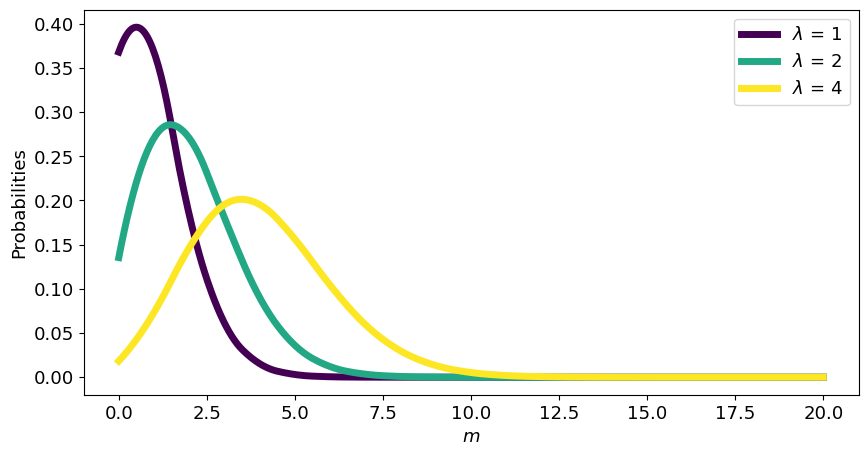

In [2]:
# creating sample Probability Mass Function (PMF) Poisson distributions, for different lambdas
# In our use case, each observation will have its own lambdai and therefore its own PMF
# The PMF Poisson distribution only depends on the lambda itself (which already incorporates the X predictors' 
# values). In fact, two observations could have the same PMF, lambda and regression params for different X variables' 
# values. This difference on predictors' values would not change the PMF, provided that the lambda is the same - the
# Poisson Distribution only depends on the lambda.

# defining a PMF Poisson distribution function (see formula at the above picture), based on a custom lambda - that 
# defines the Distribution - and an m value, whose probability of happening we wish to know, as the function result. 
# We use this function to calculate multiple sample m probabilities and plot the PMF graph. Or we could use it 
# to calculate the probability for any particular m at a concrete problem (if using the lambda of the problem), 
# including the prob for the mean of m(s), i.e., the prob for lambda.
def poisson_pmf(lmbda,m):
    return (exp(-lmbda) * lmbda ** m) / factorial(m)

# plotting different Poisson PMFs for 3 different sample lambdas. This is simple demonstration of random lambda PMFs
# Poisson distributions and have nothing to do with our dataset. For our actual dataset, we'll plot different PMFs 
# later, when we calculate the actual lambda from the predictors (at each observation).
m = np.arange(0,21)
lmbda_1_pmf = []
lmbda_2_pmf = []
lmbda_4_pmf = []
for item in m:
    lmbda_1_pmf.append(poisson_pmf(1,item))
    lmbda_2_pmf.append(poisson_pmf(2,item))
    lmbda_4_pmf.append(poisson_pmf(4,item))

# putting those pmf results into a df
lambda_pmf_df = pd.DataFrame({'m':m,
                          'lambda_1_pmf':lmbda_1_pmf,
                          'lambda_2_pmf':lmbda_2_pmf,
                          'lambda_4_pmf':lmbda_4_pmf})

# plotting the df into a graph
def smooth_line_plot(x,y):
    x_new = np.linspace(x.min(), x.max(),500)
    f = interp1d(x, y, kind='quadratic')
    y_smooth=f(x_new)
    return x_new, y_smooth
x_new, lambda_1_pmf = smooth_line_plot(lambda_pmf_df.m, lambda_pmf_df.lambda_1_pmf)
x_new, lambda_2_pmf = smooth_line_plot(lambda_pmf_df.m, lambda_pmf_df.lambda_2_pmf)
x_new, lambda_4_pmf = smooth_line_plot(lambda_pmf_df.m, lambda_pmf_df.lambda_4_pmf)
plt.figure(figsize=(10,5))
plt.plot(x_new, lambda_1_pmf, linewidth=5, color='#440154FF')
plt.plot(x_new, lambda_2_pmf, linewidth=5, color='#22A884FF')
plt.plot(x_new, lambda_4_pmf, linewidth=5, color='#FDE725FF')
plt.xlabel('m', fontsize=13, style='italic')
plt.ylabel('Probabilities', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend([r'$\lambda$ = 1',r'$\lambda$ = 2',r'$\lambda$ = 4'], fontsize=13)
plt.show()

# observe that in a Poisson PMF Distribution of integers (count), among the m possible values, the lambda - the mean -
# is the one with highest probability, although, in some cases, m=lambda-1 - the mode - can have that same prob as 
# well. The probs for all other m counts are lower. By default, the predictions of Poisson models, at each observation, 
# will always return the mean m, i.e., the lambda, as the fitted Yhat value - because, for that particular PMF 
# distribution, that lambda is the count with highest probability of happening. Although it's not impossible for other
# m counts to happen, instead (each one with a defined - though lower - probability).

In [3]:
# NOW, getting back to our actual use case dataset:
# reading and displaying our dataset
# "violations" are parking violation tickets; "staff" is the number of diplomats of that country in NYC, subject to 
# commiting a parking violation; "post" means a dicotomic dummy variable that tells us if the enforcement law had 
# already been implemented (yes) or not (no); and "corruption" is a corruption index score that measures corruption 
# at the original respective country
corruption_df = pd.read_csv('corruption.csv', delimiter=',')
corruption_df

,country,code,violations,staff,post,corruption
0,Angola,AGO,50,9,no,1.047506
1,Angola,AGO,1,9,yes,1.047506
2,Albania,ALB,17,3,no,0.921079
3,Albania,ALB,0,3,yes,0.921079
4,United Arab Emirates,ARE,0,3,no,-0.779468
...,...,...,...,...,...,...
293,Zaire,ZAR,0,6,yes,1.582807
294,Zambia,ZMB,37,9,no,0.562193
295,Zambia,ZMB,0,9,yes,0.562193
296,Zimbabwe,ZWE,43,14,no,0.133379


In [4]:
corruption_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 298 entries, 0 to 297
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     298 non-null    str    
 1   code        298 non-null    str    
 2   violations  298 non-null    int64  
 3   staff       298 non-null    int64  
 4   post        298 non-null    str    
 5   corruption  298 non-null    float64
dtypes: float64(1), int64(2), str(3)
memory usage: 14.1 KB


In [5]:
corruption_df.describe()

,violations,staff,corruption
count,298.000000,298.000000,298.000000
mean,6.496644,11.805369,0.013641
std,18.210377,11.079558,1.012474
min,0.000000,2.000000,-2.582988
25%,0.000000,6.000000,-0.415147
50%,0.000000,9.000000,0.326959
75%,3.000000,14.000000,0.720250
max,167.000000,86.000000,1.582807


In [6]:
# plotting a world corruption map based on the dataset above, considered code, country and corruption columns
fig = px.choropleth(
    corruption_df, 
    locations='code',
    locationmode='ISO-3',
    color='corruption',
    hover_name='country',
    color_continuous_scale=[
        "#2c7bb6",
        "#abd9e9",
        "#1a1a1a",
        "#fdae61",
        "#d7191c"
    ],
    range_color=(-1, 1),
    projection="natural earth",
    title="Corruption Index by Country",
    template="plotly_dark"
)

fig.update_layout(
    paper_bgcolor='#000000',
    plot_bgcolor='#000000',
    font=dict(color='white'),
    title_x=0.5
)

fig.update_geos(
    showcountries=True,
    countrycolor="#444",
    showcoastlines=False,
    showland=True,
    landcolor="#0a0a0a",
    showocean=True,
    oceancolor="#000000"
)

fig.show()

In [7]:
# calculating frequencies for observed violations m counts by country per year per diplomat
# the m counts are the number of violations, committed eventually by more than one contry, while the frequency is 
# the number of countries that coincidently commited that same number m of violations
# What is modelled at Poisson PMF Distribution is the count of violations commited, irrespective to the frequency of
# countries that have actually commited each same amout of violations
# At our case, the count values of our dependent variable varies with a min of 0 and a max of 167 (observed values)
# When created the model, each observation (country) will have its own PMF with counts of violations possibly varying 
# from 0 to any non-negative integer, and the mean count being each observation's lambda. Those m, at the model, are
# the predictable counts, each with a certain probability, and by default the Yhati predicted will be the lambdai
# The % frequency here is simply a frequency of observed violations, not a model probability of a PMF... we haven't
# even created the model yet. This is just descriptive analysis, and not predictive analysis, so far.
count = corruption_df['violations'].value_counts(dropna=False)
percent = (corruption_df['violations'].value_counts(dropna=False, normalize=True)*100).round(2)
table = pd.concat([count, percent], axis=1, keys=['frequency', '%'], sort=True)
table

,frequency,%
violations,,
0,156,52.35
1,35,11.74
2,16,5.37
3,17,5.70
4,5,1.68
5,10,3.36
6,3,1.01
7,4,1.34
8,3,1.01


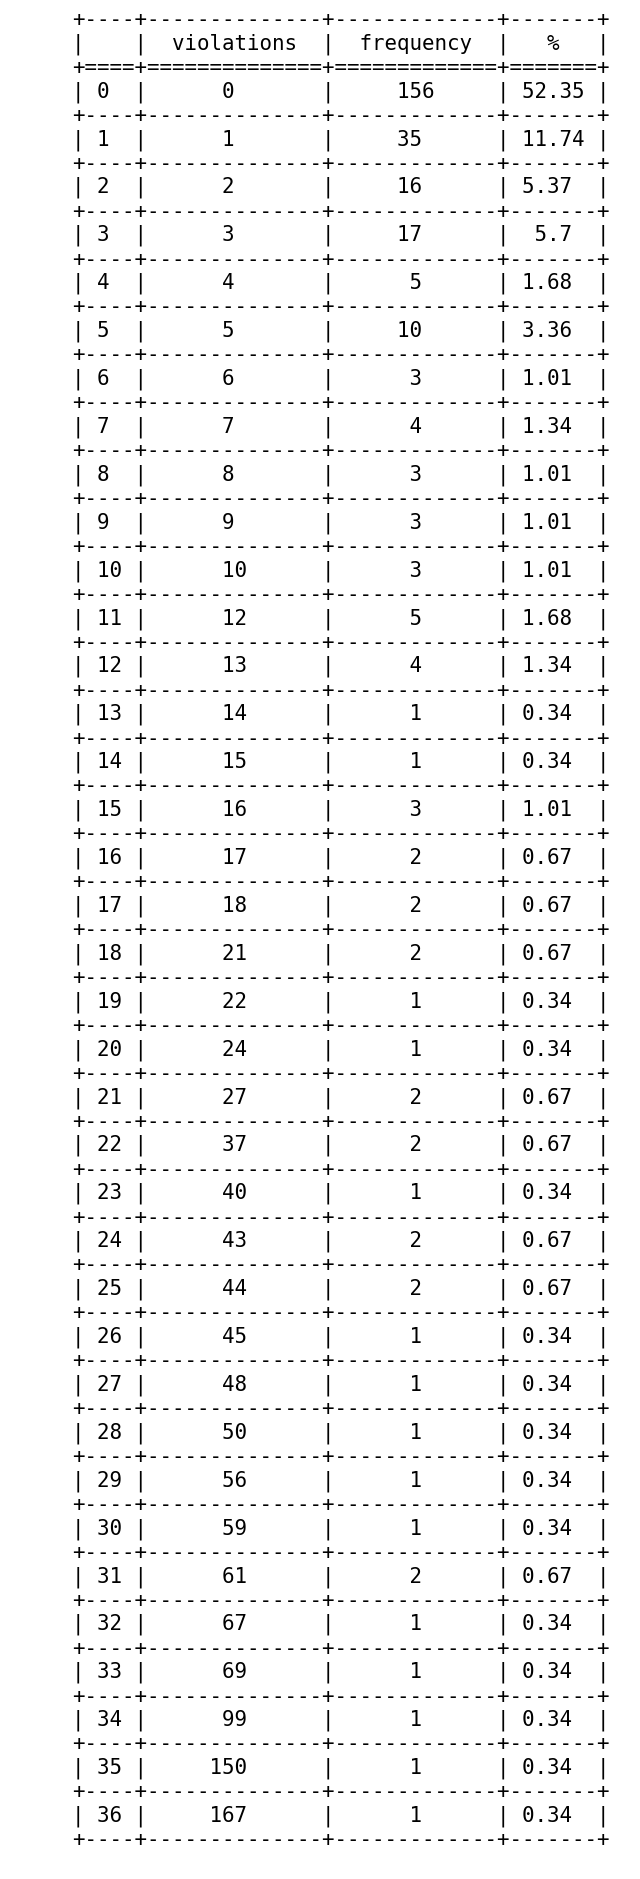

In [8]:
# putting the observed values table above at a better tabular display
table.reset_index(level=0, inplace=True)
table.rename(columns={'index': 'n'}, inplace=True)
tabela = tabulate(table, headers='keys', tablefmt='grid', numalign='center')
plt.figure(figsize=(8, 3))
plt.text(0.1, 0.1, tabela, {'family': 'monospace', 'size': 15})
plt.axis('off')
plt.show()

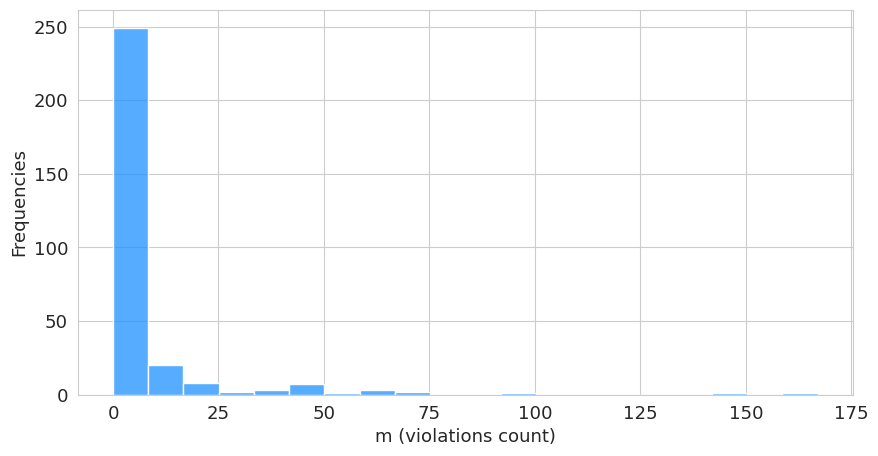

In [9]:
# plotting an histogram for the above frequencies of each observed m counts of the dependent variable (violations)
# This frequency is simply descriptive (not predictivity), regardig observed values at the dataset
with sns.axes_style("whitegrid"):
    plt.figure(figsize=(10,5))
    sns.histplot(data=corruption_df, x='violations', bins=20,
                 color='dodgerblue', edgecolor='white', kde=False)
    plt.xlabel('m (violations count)', fontsize=13)
    plt.ylabel('Frequencies', fontsize=13)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.show()

In [10]:
# preliminar analysis of mean vs variance of the dependent variable (violations)
# if mean = variance, we have a Poisson distribution; if variance >>> mean, we have a negative binomial distribution
# on next projects we'll also evaluate zero inflation, as well
pd.DataFrame({'Mean':[corruption_df.violations.mean()],
              'Variance':[corruption_df.violations.var()]})

# but we can see, first-hand, that the variance is much bigger than the mean. We must confirm that statistically,
# through the Cameron and Trevedi superdispersion test, shown down below

,Mean,Variance
0,6.496644,331.617834


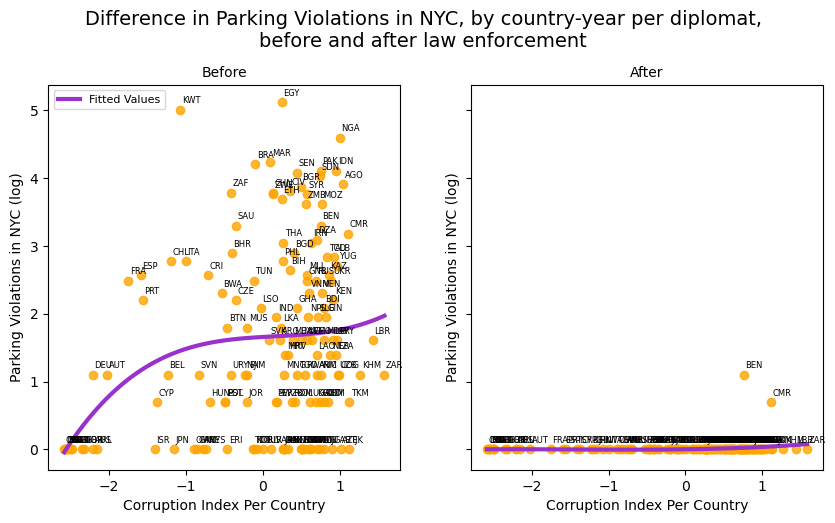

In [11]:
# change on violations per country per year per diplomat before and after (post=no vs post=yes) law enforcement
# i.e., the effect law enforcement had, in 2022, on the dependent variable (violations)
# observe that law enforcement almost eliminated unpaid parking tickets by almost all countries, specially the
# most corrupted ones, who had the higher m counts (violations) per country per year per diplomat

fig, axs = plt.subplots(ncols=2, figsize=(10,5), sharey=True)
fig.suptitle('Difference in Parking Violations in NYC, by country-year per diplomat,\nbefore and after law enforcement',
             fontsize=14, y=1.03)
post = ['no', 'yes']
labels = {'no': 'Before', 'yes': 'After'}
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']+.02, point['y']+.1, str(point['val']), fontsize=6)

for i, v in enumerate(post):
    df = corruption_df[corruption_df.post==v]
    df['violations'] = np.log(df.violations)
    df.loc[df['violations'] == np.inf, 'violations'] = 0
    df.loc[df['violations'] == -np.inf, 'violations'] = 0
    sns.regplot(data=df, x='corruption', y='violations',
                order=3, ax=axs[i], ci=False,
                line_kws={'color':'darkorchid', 'linewidth': 3,
                          'label':'Fitted Values'},
                scatter_kws={'color':'orange'})
    axs[i].set_title(labels[v], fontsize=10)
    axs[i].set_ylabel("Parking Violations in NYC (log)", fontsize=10)
    axs[i].set_xlabel("Corruption Index Per Country", fontsize=10)
    label_point(df.corruption, df.violations, df.code, axs[i])

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=10)
    
axs[0].legend(loc='upper left', fontsize=8)

plt.show()

In [12]:
# proceeding with Poisson predictive model creation
poisson_model = sm.Poisson.from_formula('violations ~ staff + post + corruption',
                                         data=corruption_df).fit()
poisson_model.summary()

Optimization terminated successfully.
         Current function value: 6.952328
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Poisson Regression Results                          
==============================================================================
Dep. Variable:             violations   No. Observations:                  298
Model:                        Poisson   Df Residuals:                      294
Method:                           MLE   Df Model:                            3
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3992
Time:                        04:03:20   Log-Likelihood:                -2071.8
converged:                       True   LL-Null:                       -3448.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.2127      0.031     71.134      0.000       2.152       2.274
post[T.yes]    -4.2968      0.197    -21.762      0.000      -4.684      -3.910
staff           0.0219      0.001     17.807      0.000       0.019       0.024
corruption      0.3418      0.027     12.430      0.000       0.288       0.396
===============================================================================
"""

In [13]:
summary_col([poisson_model],
            model_names=["MODEL"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs)),
                'Log-lik':lambda x: "{:.2f}".format(x.llf)
        })

,MODEL
Intercept,2.2127***
,(0.0311)
post[T.yes],-4.2968***
,(0.1974)
staff,0.0219***
,(0.0012)
corruption,0.3418***
,(0.0275)
N,298
Log-lik,-2071.79


In [14]:
# Observe, at the above model, that all predictive variables' p-values were all very much significant, as well as the 
# LLR p-value of the model as a whole - when compared the gain of the current model (with its predictors) with a null 
# model (with no predictors).

# So, although it is a statistically valid Poisson model, and we could use it as it is, we can't say it's the best 
# option of Count model type to use. We gotta check superdispersion and zero inflation to conclude which model type 
# is better, including by comparing all possible models' LLFs, to see which one approximates most to zero

In [15]:
# At the histogram for the frequencies of m, above, we already inferred an existent superdispersion. Let's confirm it,
# statistically, by using the Cameron and Trevedi superdispersion test (see picture with formulas at the beggining)

# 1st step: estimate a Poisson model and predict values for every observation (lambdai)
# 2nd step: create a new Y* variable at the df and calculate each value of it using the formula:
# Yi* = ((Yi - lambdai)^2 - Yi) / lambdai
# This Yi* compares and normalize the sq of errors between observed Yi and predicted Yhati (lambdai) at the 
# Poisson model, for later using it at the OLS regression test below
# 3rd step: estimate an auxiliary model OLS, with the Y* variable above, as dependent variable, and the lambdai,
# predicted at the Poisson model, as only predictor, without intercept
# 4th step: observe significance of beta param for this OLS test model:
# β p-value >= 0.05, there's no significant difference, therefore there is no superdispersion => equidispersion
# β p-value < 0.05, there is overdispersion => should be used Negative Binomial, not Poisson

# Calculating and Adding the fitted values (lambdai) of Poisson Model at the df
corruption_df['lambda_poisson'] = pd.DataFrame(poisson_model.predict(linear=False))

# Calculating and Adding the new variable Y* ('ystar')
corruption_df['ystar'] = (((corruption_df['violations']
                            -corruption_df['lambda_poisson'])**2)
                          -corruption_df['violations'])/corruption_df['lambda_poisson']
corruption_df

,country,code,violations,staff,post,corruption,lambda_poisson,ystar
0,Angola,AGO,50,9,no,1.047506,15.919915,69.815208
1,Angola,AGO,1,9,yes,1.047506,0.216711,-1.783289
2,Albania,ALB,17,3,no,0.921079,13.371720,-0.286843
3,Albania,ALB,0,3,yes,0.921079,0.182023,0.182023
4,United Arab Emirates,ARE,0,3,no,-0.779468,7.477915,7.477915
...,...,...,...,...,...,...,...,...
293,Zaire,ZAR,0,6,yes,1.582807,0.243691,0.243691
294,Zambia,ZMB,37,9,no,0.562193,13.486751,38.250347
295,Zambia,ZMB,0,9,yes,0.562193,0.183589,0.183589
296,Zimbabwe,ZWE,43,14,no,0.133379,12.994217,65.979120


In [16]:
# Estimating the OLS model without the intercept (dependent variable is the Y* statistic above and the only predictor
# is the lambdai predicted at the Poisson model)
auxiliary_model = sm.OLS.from_formula('ystar ~ 0 + lambda_poisson', corruption_df).fit()
auxiliary_model.summary()

# Observe below that the t Student test for the only predictor (lambda_poisson) has p-value < 0.05, therefore this
# predictor is significant on explaining Y* statistic, which means we have superdispersion, and should not use Poisson
# distribution, but negative binomial distribution, instead, in order to fit better the whole dispersion tail of our 
# dataset, and hopefuly reach better llf scores for our Count Data model.

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  ystar   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):              0.022
Method:                 Least Squares   F-statistic:                              7.584
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                     0.00625
Time:                        04:03:20   Log-Likelihood:                         -1952.9
No. Observations:                 298   AIC:                                      3908.
Df Residuals:                     297   BIC:                                      3911.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
lambda_poisson     2.6525      0.963      2.754      0.006       0.757       4.548
==============================================================================
Omnibus:                      607.263   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           446004.649
Skew:                          13.265   Prob(JB):                         0.00
Kurtosis:                     190.659   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# for testing overdispersion above, we could also use the statstests.tests already available method overdisp() 
# For this method, we just have to pass the Count model we're testing and the dataset df, and it'll do all steps above
# internally and give us a result, at once
overdisp(poisson_model, corruption_df)

Estimating overdispersion test for model type: PoissonResultsWrapper...

                        Results: Ordinary least squares
Model:                  OLS              Adj. R-squared (uncentered): 0.022    
Dependent Variable:     y                AIC:                         3907.7809
Date:                   2026-04-14 04:03 BIC:                         3911.4780
No. Observations:       298              Log-Likelihood:              -1952.9  
Df Model:               1                F-statistic:                 7.584    
Df Residuals:           297              Prob (F-statistic):          0.00625  
R-squared (uncentered): 0.025            Scale:                       28915.   
-------------------------------------------------------------------------------------
            Coef.        Std.Err.         t          P>|t|        [0.025       0.975]
-------------------------------------------------------------------------------------
x1          2.6525         0.9632       2.7538       

In [53]:
# Supposing we still wished to use the Poisson distribution in our model, let's just do some specific predictions:

# What would be the expected mean number of traffic violations (lambdai) for a country whose diplomatic corps consists 
# of 23 members, considering the period before the law came into effect (post=0), and whose corruption index is equal 
# to 0.5?
lambdai_prediction_before = poisson_model.predict(pd.DataFrame({
    'staff':[23],
    'post':['no'],
    'corruption':[0.5]
}))[0]
m_prediction_before = int(round(lambdai_prediction_before))  # closest integer to λ
prob_prediction_before = stats.poisson.pmf(m_prediction_before, lambdai_prediction_before)

# What would be the expected mean number of traffic violations for the same country, but now considering the period 
# after the law came into effect?
lambdai_prediction_after = poisson_model.predict(pd.DataFrame({
    'staff':[23],
    'post':['yes'],
    'corruption':[0.5]
}))[0]
m_prediction_after = int(round(lambdai_prediction_after))  # closest integer to λ
prob_prediction_after = stats.poisson.pmf(m_prediction_after, lambdai_prediction_after)

print(f"For a country with 23 diplomats and corruption score of 0.5, we'd expect the mean number of violations (lambdai) to be {m_prediction_before} (lambdai = {lambdai_prediction_before}), with a probability of {round(prob_prediction_before*100,0)}%, before the 2002 enforcement of the law, and {m_prediction_after} (lambdai = {lambdai_prediction_after}), with a probability of {round(prob_prediction_after*100,0)}%, after law started being implemented.")

# Observe that the lambdai value itself is a mean, i.e., a continuous real-based value, while the m counts of the 
# event, on the other hand, is discrete and integer-based. When we say lambdai is the count with best probability of 
# occuring, we're actually considering lambdai as the nearest m count integer closer to its float value... rounding 
# the lambda float into an integer, as any count (m) must be integer-based. More than one m count, just around the 
# value of lambdai, may have the same maximum probability, which is assumed to be the probability of lambdai itself. 
# As we move farther away from the value of lambdai, the m values' probabilities decrease.

For a country with 23 diplomats and corruption score of 0.5, we'd expect the mean number of violations (lambdai) to be 18 (lambdai = 17.93283965363334), with a probability of 9.0%, before the 2002 enforcement of the law, and 0 (lambdai = 0.24411195340024439), with a probability of 78.0%, after law started being implemented.


Finally, keep in mind that for each country for which we estimate the number of violations, as Yhati = lambdai, there is a unique Poisson probability mass function (PMF), since each country has its own lambdai, which is used to define the PMF. In the case of our model, for the 298 countries, we have 298 different Poisson distributions. This makes it impractical to represent the model with a single PMF graph.

A histogram of frequencies (frequency versus m) aggregates all observed values m across countries into a single empirical distribution, regardless of their individual λᵢ values. It simply describes the observed data and does not depend on any model or prediction.

A probability distribution (probability versus m), on the other hand, is model-based and depends essentially on each observation λᵢ. In count data models, this implies that the full probabilistic output consists of as many PMFs as there are observations with distinct λᵢ values.

The model’s predict() method does not create or “consult” each PMF internally, but instead computes λᵢ directly from the predictors using the estimated regression params (coefficients). This λᵢ is the expected value (mean) of the corresponding Poisson distribution. Knowing this lambdai, you can calculate the probability of the lambda or any other m at the same PMF just by using the Poisson PMF formula. You don't need to generate each PMF distribution for that. Just use the regression for the lambdai, and then the PMF for the probability of the lambdai or of any other m.